# Final Model and Results for Faces Dataset

In this notebook, we implement the final convolutional neural network (CNN) model to classify images as either 'real' or 'fake' faces. The improvement in this model compared to the baseline model previously created, is that we adjusted the architecture of the model using gridsearch and added adaptive learning rate reduction during training.

## Table of Contents
1. [Imports and Setup](#imports-and-setup)
2. [Data Preparation](#data-preparation)
3. [Model Building](#model-building)
4. [Model Training](#model-training)
5. [Model Evaluation](#model-evaluation)

### Imports and Setup

In [1]:
import sys
import os
import tensorflow as tf
import cv2

from tensorflow.keras import layers, models, optimizers, regularizers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score, classification_report

from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

### Data Preparation

In this section we mounted the data to colab, loaded and cleaned (from added computer files) the datasets. Lastly, we preprocessed the pixel range of the images to be in [0, 1].

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!unzip /content/drive/MyDrive/dataset_train.zip -d /content/dataset_train/

Archive:  /content/drive/MyDrive/dataset_train.zip
  inflating: /content/dataset_train/__MACOSX/._dataset_train  
  inflating: /content/dataset_train/dataset_train/.DS_Store  
  inflating: /content/dataset_train/__MACOSX/dataset_train/._.DS_Store  
  inflating: /content/dataset_train/__MACOSX/dataset_train/._real  
  inflating: /content/dataset_train/__MACOSX/dataset_train/._fake  
replace /content/dataset_train/dataset_train/real/14147.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
!unzip /content/drive/MyDrive/dataset_test.zip -d /content/dataset_test/

Archive:  /content/drive/MyDrive/dataset_test.zip
  inflating: /content/dataset_test/__MACOSX/._dataset_test  
  inflating: /content/dataset_test/dataset_test/.DS_Store  
  inflating: /content/dataset_test/__MACOSX/dataset_test/._.DS_Store  
  inflating: /content/dataset_test/__MACOSX/dataset_test/._real  
  inflating: /content/dataset_test/__MACOSX/dataset_test/._fake  
replace /content/dataset_test/dataset_test/real/19463.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
def load_image_dataset(data_path, batch_size=32, img_size=(200, 200), subset_ratio=1.0):
    """
    Load images from the specified directory.

    Expects structure:
       data_path/real/...
       data_path/fake/...

    Parameters:
        data_path (str): Path to dataset (e.g., "dataset_train" or "dataset_test").
        batch_size (int): Number of images per batch.
        img_size (tuple): Target image size.
        subset_ratio (float): Fraction of the dataset to use (default 1.0 = all).

    Returns:
        A tf.data.Dataset object ready for training/testing and the class names.
    """
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_path,
        labels='inferred',
        label_mode='binary',
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True
    )
    class_names = dataset.class_names

    if subset_ratio < 1.0:
        total_batches = tf.data.experimental.cardinality(dataset).numpy()
        subset_batches = int(total_batches * subset_ratio)
        dataset = dataset.take(subset_batches)

    return dataset, class_names

In [6]:
import os
def clean_dataset(directory):
    allowed_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

    for root, dirs, files in os.walk(directory):
        for file in files:
            ext = os.path.splitext(file)[-1].lower()
            if ext not in allowed_extensions:
                file_path = os.path.join(root, file)
                print(f"Deleting non-image file: {file_path}")
                os.remove(file_path)

# Clean train and test folders
clean_dataset("/content/dataset_train")
clean_dataset("/content/dataset_test")

Deleting non-image file: /content/dataset_train/__MACOSX/._dataset_train
Deleting non-image file: /content/dataset_train/__MACOSX/dataset_train/._.DS_Store
Deleting non-image file: /content/dataset_train/__MACOSX/dataset_train/._fake
Deleting non-image file: /content/dataset_train/__MACOSX/dataset_train/._real
Deleting non-image file: /content/dataset_train/dataset_train/.DS_Store
Deleting non-image file: /content/dataset_test/__MACOSX/._dataset_test
Deleting non-image file: /content/dataset_test/__MACOSX/dataset_test/._.DS_Store
Deleting non-image file: /content/dataset_test/__MACOSX/dataset_test/._fake
Deleting non-image file: /content/dataset_test/__MACOSX/dataset_test/._real
Deleting non-image file: /content/dataset_test/dataset_test/.DS_Store


In [7]:
!rm -r /content/dataset_test/__MACOSX
!rm -r /content/dataset_train/__MACOSX

In [8]:
def scale_images_to_unit_range(dataset):
    """
    Applies scaling to images in the dataset so that their pixel values are in the [0, 1] range.
    """
    def scaling_fn(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scaling_fn)

In [9]:
batch_size = 32
img_size = (200,200)
img_width, img_height = img_size

train_data_path = "/content/dataset_train/dataset_train"
test_data_path = "/content/dataset_test/dataset_test"

In [10]:
train_dataset, class_names = load_image_dataset(
    train_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=1.0
)
train_dataset = scale_images_to_unit_range(train_dataset)

test_dataset, _ = load_image_dataset(
    test_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=1.0
)
test_dataset = scale_images_to_unit_range(test_dataset)

train_count = tf.data.experimental.cardinality(train_dataset).numpy()
test_count = tf.data.experimental.cardinality(test_dataset).numpy()

print(f"Number of training batches: {train_count}")
print(f"Number of validation batches: {test_count}\n")

print(f"Approximate number of training images: {train_count * batch_size}")
print(f"Approximate number of validation images: {test_count * batch_size}")

print(f"Class names: {class_names}")

Found 96767 files belonging to 2 classes.
Found 24192 files belonging to 2 classes.
Number of training batches: 3024
Number of validation batches: 756

Approximate number of training images: 96768
Approximate number of validation images: 24192
Class names: ['fake', 'real']


In the next sections, we will build and train our model, plot its training history on both our training and validation data then test it on our test dataset to obtain the final accuracy results. We will finally look at the F1 score for our model to better understand its performance. Lastly, we will look at Grad-CAM plots.

### Model Building

We build a CNN.

In [11]:
def create_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

### Model Training

In [12]:
def train_model(train_dataset, test_dataset, input_shape, epochs=15, batch_size=32):
    model = create_model(input_shape)

    callbacks = [
        EarlyStopping(patience=3, monitor='val_loss', restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=3, min_lr=1e-6),
        ModelCheckpoint("faces_final_model.h5", save_best_only=True, monitor='val_loss')
    ]

    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history, model

In [13]:
input_shape = (img_height, img_width, 3)  # (200, 200, 3)

history, model = train_model(train_dataset, test_dataset, input_shape, epochs=8, batch_size=32)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7473 - loss: 0.5148

3024/3024 ━━━━━━━━━━━━━━━━━━━━ 211s 66ms/step - accuracy: 0.7473 - loss: 0.5148 - val_accuracy: 0.8910 - val_loss: 0.2685 - learning_rate: 1.0000e-04
Epoch 2/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8932 - loss: 0.2651

3024/3024 ━━━━━━━━━━━━━━━━━━━━ 184s 61ms/step - accuracy: 0.8932 - loss: 0.2651 - val_accuracy: 0.9200 - val_loss: 0.2003 - learning_rate: 1.0000e-04
Epoch 3/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9396 - loss: 0.1632

3024/3024 ━━━━━━━━━━━━━━━━━━━━ 184s 61ms/step - accuracy: 0.9396 - loss: 0.1632 - val_accuracy: 0.9544 - val_loss: 0.1259 - learning_rate: 1.0000e-04
Epoch 4/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 183s 61ms/step - accuracy: 0.9578 - loss: 0.1168 - val_accuracy: 0.9403 - val_loss: 0.1592 - learning_rate: 1.0000e-04
Epoch 5/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9692 - loss: 0.0855

3024/3024 ━━━━━━━━━━━━━━━━━━━━ 183s 61ms/step - accuracy: 0.9692 - loss: 0.0855 - val_accuracy: 0.9592 - val_loss: 0.1126 - learning_rate: 1.0000e-04
Epoch 6/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 190s 63ms/step - accuracy: 0.9777 - loss: 0.0626 - val_accuracy: 0.9379 - val_loss: 0.1677 - learning_rate: 1.0000e-04
Epoch 7/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 183s 61ms/step - accuracy: 0.9831 - loss: 0.0482 - val_accuracy: 0.9596 - val_loss: 0.1354 - learning_rate: 1.0000e-04
Epoch 8/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 202s 61ms/step - accuracy: 0.9857 - loss: 0.0398 - val_accuracy: 0.8949 - val_loss: 0.3396 - learning_rate: 1.0000e-04


We plot the training history of our CNN.

In [14]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.plot(epochs_range, acc, 'b', label='Training accuracy')
    plt.plot(epochs_range, val_acc, 'r', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs_range, loss, 'b', label='Training loss')
    plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

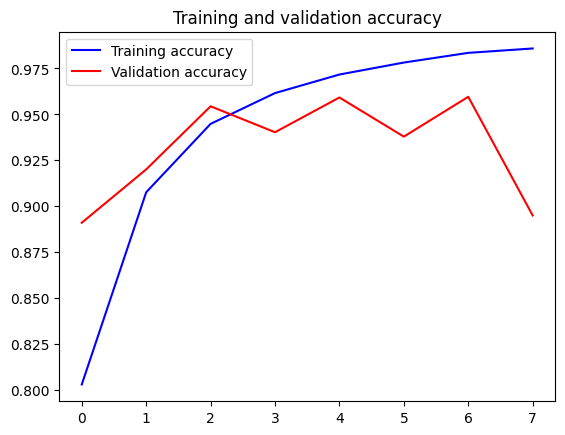

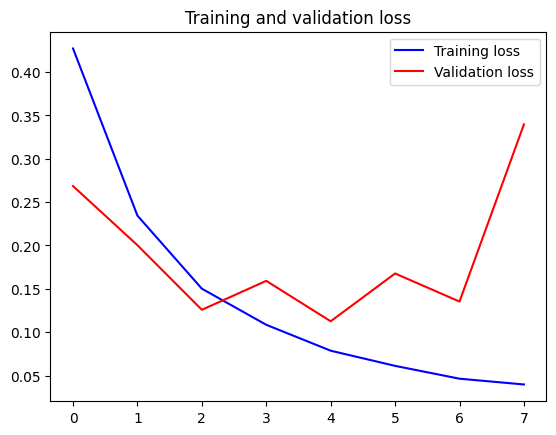

In [15]:
plot_history(history)

### Saving the model's weights

In [16]:
def save_model_weights(model, filename="faces_final_model.h5", download=False):
    """
    Save the Keras model weights and optionally download them in Colab.

    Args:
        model: Trained Keras model.
        filename: Name of the file to save weights.
        download: Whether to trigger download in Colab.
    """
    model.save_weights(filename)
    print(f"Model weights saved to {filename}")

    if download:
        try:
            from google.colab import files
            files.download(filename)
            print("Download started...")
        except Exception as e:
            print("Download failed (are you running outside of Colab?):", e)

In [17]:
# Save locally
# save_model_weights(model, filename="faces_final_model.h5")

# Save + download if in Colab
save_model_weights(model, filename="faces_final_model.h5", download=True)

ValueError: The filename must end in `.weights.h5`. Received: filepath=faces_final_model.h5

### Model Evaluation

We test our CNN on our test data and observe its F1 score.

In [ ]:
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

In [ ]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_pred_probs = model.predict(test_dataset)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv2d_4"):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_gradcam(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    color_heatmap = cv2.applyColorMap(heatmap, colormap)
    overlayed = cv2.addWeighted(img, 1 - alpha, color_heatmap, alpha, 0)
    return overlayed

In [ ]:
# Get one batch from the dataset
for images, labels in test_dataset.take(1):
    img = images[0]  # shape (H, W, 3), scaled float32
    label = labels[0]
    break

# Prepare for model input
img_array = tf.expand_dims(img, axis=0)  # shape (1, H, W, 3)

# Convert for overlay (needs uint8)
original_img = (img.numpy() * 255).astype("uint8")

In [ ]:
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv2d_4")
overlayed_img = overlay_gradcam(original_img, heatmap)

plt.figure(figsize=(6, 6))
plt.imshow(overlayed_img)
plt.axis("off")
plt.title("Grad-CAM")
plt.show()
